In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Caminho do arquivo CSV
file_path = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materia7-EstatisticaComPython/IA/IA em análise de Dados/sales data-set.csv"

# Carregar o CSV em um DataFrame
df = pd.read_csv(file_path)

# Mostrar as 5 primeiras linhas
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [14]:
# Mostrar a lista de colunas
df.columns.tolist()

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

In [15]:
# Converter a coluna Date para datetime (formato dia/mês/ano)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Calcular mínimo e máximo da coluna Date
date_min = df["Date"].min()
date_max = df["Date"].max()

print("Data mínima:", date_min)
print("Data máxima:", date_max)

Data mínima: 2010-02-05 00:00:00
Data máxima: 2012-10-26 00:00:00


In [16]:
# Extrair mês e ano em novas colunas
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

# Exibir as primeiras linhas para conferir
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Month,Year
0,1,1,2010-02-05,24924.50,False,2,2010
1,1,1,2010-02-12,46039.49,True,2,2010
2,1,1,2010-02-19,41595.55,False,2,2010
3,1,1,2010-02-26,19403.54,False,2,2010
4,1,1,2010-03-05,21827.90,False,3,2010


In [17]:
# Agrupar por ano e mês e somar Weekly_Sales
grouped = (
    df.groupby(["Year", "Month"])["Weekly_Sales"]
      .sum()
      .reset_index()
)

# Visualizar as primeiras linhas e o formato do resultado
grouped.head()


,Year,Month,Weekly_Sales
0,2010,2,1.903330e+08
1,2010,3,1.819198e+08
2,2010,4,2.314124e+08
3,2010,5,1.867109e+08
4,2010,6,1.922462e+08


In [18]:
print(grouped.shape)

(33, 3)


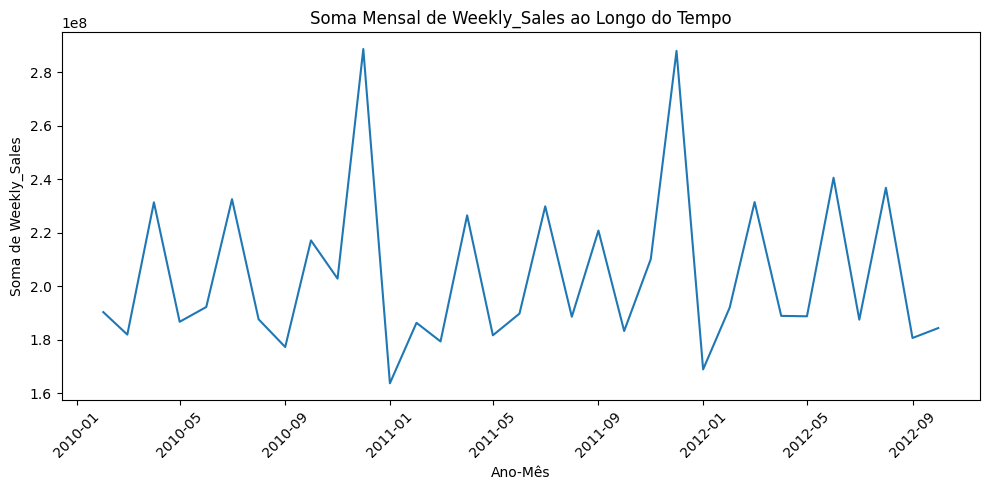

In [19]:
grouped["YearMonth"] = pd.to_datetime(
    dict(year=grouped["Year"], month=grouped["Month"], day=1)
)

# Plotar gráfico temporal
plt.figure(figsize=(10, 5))
plt.plot(grouped["YearMonth"], grouped["Weekly_Sales"])
plt.xlabel("Ano-Mês")
plt.ylabel("Soma de Weekly_Sales")
plt.title("Soma Mensal de Weekly_Sales ao Longo do Tempo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()